# Developer Skills & Role Detection
**Objective:** Automatically detect developer roles (Frontend, Backend, Tester, DevOps, Full Stack, Generalist) from Git history.

**Repo used:** https://github.com/pallets/flask

## 1. Install dependencies

In [1]:
!pip install pydriller scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports

In [2]:
from pydriller import Repository
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


## 3. Configuration

In [3]:
REPO_URL = '/home/othmane/Documents/PFE/github-analyzer/nocodb'

# ---------- File extension classification ----------
FRONTEND_EXTENSIONS  = {'.css', '.html', '.scss', '.vue'}  # JS/TS handled by folder logic
BACKEND_PY_EXT       = {'.py'}
BACKEND_JAVA_EXT     = {'.java', '.kt', '.scala'}
DEVOPS_EXTENSIONS    = {'.yml', '.yaml', '.sh', '.dockerfile', '.toml', '.cfg', '.ini'}
BUILD_FILES          = {'pom.xml', 'build.gradle', 'requirements.txt', 'setup.py',
                        'setup.cfg', 'pyproject.toml', 'package.json', 'build.xml'}
DOC_EXTENSIONS       = {'.md', '.rst', '.txt', '.adoc'}

# Files that are always DevOps regardless of extension
DEVOPS_FILENAMES     = {'dockerfile', 'jenkinsfile', 'makefile', '.travis.yml',
                        'docker-compose.yml', 'docker-compose.yaml'}

# Test folder detection
TEST_FOLDER_KEYWORDS = {'test', 'tests', 'spec', 'specs', '__tests__'}

# JS/TS folder classification
BACKEND_FOLDERS  = {'server', 'backend', 'api', 'services', 'routes',
                    'controllers', 'models', 'db', 'database', 'middleware',
                    'worker', 'queue'}
FRONTEND_FOLDERS = {'client', 'frontend', 'ui', 'components', 'pages',
                    'views', 'hooks', 'stores', 'public', 'assets',
                    'styles', 'app'}

# ---------- Commit message keywords ----------
KEYWORDS = {
    'frontend' : ['ui', 'style', 'component', 'layout', 'css', 'html', 'design',
                  'template', 'view', 'render', 'frontend', 'front-end'],
    'backend'  : ['api', 'endpoint', 'model', 'database', 'query', 'server',
                  'backend', 'back-end', 'route', 'controller', 'service', 'orm'],
    'test'     : ['test', 'spec', 'assert', 'mock', 'coverage', 'fix', 'bug',
                  'bugfix', 'unittest', 'pytest'],
    'devops'   : ['deploy', 'docker', 'pipeline', 'ci', 'cd', 'build', 'release',
                  'workflow', 'action', 'infra', 'kubernetes', 'helm'],
    'docs'     : ['doc', 'docs', 'readme', 'documentation', 'comment', 'changelog']
}

# ---------- Role thresholds ----------
THRESHOLDS = {
    'tester'    : 0.25,
    'devops'    : 0.20,
    'fullstack' : 0.20,
    'frontend'  : 0.40,
    'backend'   : 0.35,
}

print('Configuration OK')

Configuration OK


## 4. Helper functions

In [4]:
import os

def get_file_category(filepath):
    if filepath is None:
        return 'other'

    path_lower = filepath.lower()
    filename   = os.path.basename(path_lower)
    ext        = os.path.splitext(filename)[1]
    parts      = path_lower.replace('\\', '/').split('/')

    # --- Test folder detection ---
    if any(p in TEST_FOLDER_KEYWORDS for p in parts):
        return 'test'
    if filename.startswith('test_') or filename.endswith('_test.py') or \
       filename.endswith('test.java') or 'spec' in filename:
        return 'test'

    # --- DevOps detection ---
    if filename in DEVOPS_FILENAMES or ext in DEVOPS_EXTENSIONS:
        return 'devops'

    # --- Build files ---
    if filename in BUILD_FILES:
        return 'build'

    # --- Backend Python / Java (always backend) ---
    if ext in BACKEND_PY_EXT:
        return 'backend_py'
    if ext in BACKEND_JAVA_EXT:
        return 'backend_java'

    # --- JS/TS: use folder to decide frontend vs backend ---
    if ext in {'.js', '.ts', '.jsx', '.tsx'}:
        # backend folders
        BACKEND_FOLDERS = {'server', 'backend', 'api', 'services',
                           'routes', 'controllers', 'models', 'db',
                           'database', 'middleware', 'worker', 'queue'}
        # frontend folders
        FRONTEND_FOLDERS = {'client', 'frontend', 'ui', 'components',
                            'pages', 'views', 'hooks', 'stores', 'public',
                            'assets', 'styles', 'app'}
        parts_set = set(parts)
        if parts_set & BACKEND_FOLDERS:
            return 'backend_js'
        if parts_set & FRONTEND_FOLDERS:
            return 'frontend'
        # if unclear → check filename patterns
        if any(x in filename for x in ['controller', 'router', 'service',
                                        'model', 'middleware', 'handler']):
            return 'backend_js'
        # default JS/TS to frontend if still unclear
        return 'frontend'

    # --- CSS/HTML always frontend ---
    if ext in {'.css', '.scss', '.html', '.vue'}:
        return 'frontend'

    # --- Docs ---
    if ext in DOC_EXTENSIONS:
        return 'docs'

    return 'other'

def get_keyword_scores(message):
    """
    Given a commit message, return a dict of keyword matches per role.
    Returns 1 if at least one keyword of that role is found, else 0.
    """
    if not message:
        return {role: 0 for role in KEYWORDS}
    msg = message.lower()
    scores = {}
    for role, kws in KEYWORDS.items():
        scores[role] = 1 if any(kw in msg for kw in kws) else 0
    return scores


print('Helper functions OK')

Helper functions OK


## 5. Extract data from repository

In [5]:
# Storage per developer
# lines_by_category[dev][category] = total lines (added + deleted)
lines_by_category = defaultdict(lambda: defaultdict(int))

# keyword_hits[dev][role] = number of commits with that keyword
keyword_hits      = defaultdict(lambda: defaultdict(int))

# total commits per developer
total_commits     = defaultdict(int)

print(f'Mining repository: {REPO_URL}')
print('This may take a few minutes...')

from datetime import datetime

for commit in Repository(
    REPO_URL,
    since=datetime(2023, 1, 1),
    to=datetime(2024, 1, 1)
).traverse_commits():
    dev = commit.author.email  # use email as unique developer ID
    total_commits[dev] += 1

    # --- Commit message keywords ---
    kw_scores = get_keyword_scores(commit.msg)
    for role, hit in kw_scores.items():
        keyword_hits[dev][role] += hit

    # --- File modifications ---
    for modified_file in commit.modified_files:
        filepath = modified_file.new_path or modified_file.old_path
        category = get_file_category(filepath)

        lines_changed = (modified_file.added_lines or 0) + (modified_file.deleted_lines or 0)
        lines_by_category[dev][category] += lines_changed

print(f'Done! Found {len(total_commits)} developers.')

Mining repository: /home/othmane/Documents/PFE/github-analyzer/nocodb
This may take a few minutes...
Done! Found 68 developers.


## 6. Build metrics table

In [20]:
CATEGORIES = ['frontend', 'backend_py', 'backend_java',
              'backend_js', 'test', 'devops', 'build', 'docs', 'other']

rows = []

for dev in total_commits:
    total_lines = sum(lines_by_category[dev].values())

    if total_lines == 0:
        continue

    row = {'developer': dev, 'total_commits': total_commits[dev], 'total_lines': total_lines}

    # --- Group 1: file extension percentages (weighted by lines) ---
    for cat in CATEGORIES:
        row[f'pct_{cat}'] = lines_by_category[dev][cat] / total_lines

    # Backend combined (py + java + js)
    row['pct_backend'] = row['pct_backend_py'] + row['pct_backend_java'] + row['pct_backend_js']

    # --- Group 3: commit message keyword scores (ratio of commits) ---
    n_commits = total_commits[dev]
    for role in KEYWORDS:
        row[f'kw_{role}'] = keyword_hits[dev][role] / n_commits

    rows.append(row)

df = pd.DataFrame(rows).set_index('developer')
df = df[df['total_commits'] >= 5]
print(f'Developers with 5+ commits: {len(df)}')
df.head()

Developers with 5+ commits: 28


,total_commits,total_lines,pct_frontend,pct_backend_py,pct_backend_java,pct_backend_js,pct_test,pct_devops,pct_build,pct_docs,pct_other,pct_backend,kw_frontend,kw_backend,kw_test,kw_devops,kw_docs
developer,,,,,,,,,,,,,,,,,
wingkwong.code@gmail.com,2360,491691,0.119166,0.0,0.0,0.034867,0.049132,0.113575,0.001481,0.002870,0.678908,0.034867,0.331356,0.141102,0.380932,0.061441,0.058051
ewa.agnieszka.flis@gmail.com,74,43804,0.030043,0.0,0.0,0.001050,0.003219,0.000000,0.000000,0.000228,0.965460,0.001050,0.229730,0.135135,0.324324,0.040541,0.013514
daniel@spaude.de,235,10885,0.612219,0.0,0.0,0.026918,0.328434,0.000000,0.000367,0.002480,0.029582,0.026918,0.344681,0.102128,0.255319,0.017021,0.012766
oof1lab@gmail.com,933,1578202,0.043484,0.0,0.0,0.051315,0.805542,0.000482,0.000121,0.001030,0.098026,0.051315,0.012862,0.003215,0.007503,0.013934,0.026795
86527202+dstala@users.noreply.github.com,1117,138374,0.139528,0.0,0.0,0.007501,0.268974,0.001250,0.000231,0.126368,0.456148,0.007501,0.143241,0.110116,0.708147,0.035810,0.170098


## 7. Assign roles using rules

In [21]:
def assign_role(row):
    """
    Priority order:
    1. Tester
    2. DevOps
    3. Full Stack
    4. Frontend
    5. Backend
    6. Generalist
    """
    frontend = row['pct_frontend']
    backend  = row['pct_backend']
    test     = row['pct_test']
    devops   = row['pct_devops']

    if test    >= THRESHOLDS['tester']:
        return 'Tester'
    if devops  >= THRESHOLDS['devops']:
        return 'DevOps'
    if frontend >= THRESHOLDS['fullstack'] and backend >= THRESHOLDS['fullstack']:
        return 'Full Stack'
    if frontend >= THRESHOLDS['frontend']:
        return 'Frontend'
    if backend  >= THRESHOLDS['backend']:
        return 'Backend'
    return 'Generalist'


df['role'] = df.apply(assign_role, axis=1)

print('Role distribution:')
print(df['role'].value_counts())
print()
df[['total_commits', 'total_lines', 'pct_frontend', 'pct_backend',
    'pct_test', 'pct_devops', 'role']].sort_values('total_commits', ascending=False).head(20)

Role distribution:
role
Frontend      9
Generalist    7
Tester        6
DevOps        3
Backend       2
Full Stack    1
Name: count, dtype: int64



,total_commits,total_lines,pct_frontend,pct_backend,pct_test,pct_devops,role
developer,,,,,,,
wingkwong.code@gmail.com,2360,491691,0.119166,0.034867,0.049132,0.113575,Generalist
pranavxc@gmail.com,1655,2880942,0.046906,0.056529,0.781980,0.001141,Tester
86527202+dstala@users.noreply.github.com,1117,138374,0.139528,0.007501,0.268974,0.001250,Tester
oof1lab@gmail.com,933,1578202,0.043484,0.051315,0.805542,0.000482,Tester
mertmit99@gmail.com,768,163967,0.283472,0.124129,0.019034,0.013606,Generalist
mustafa@nocodb.com,667,31752,0.733907,0.027116,0.064846,0.049981,Frontend
daniel@spaude.de,235,10885,0.612219,0.026918,0.328434,0.000000,Tester
sreeharivijaya2003@gmail.com,208,8315,0.912087,0.000601,0.014432,0.038485,Frontend
anbarasun123@gmail.com,191,8405,0.877335,0.021892,0.042713,0.000000,Frontend


## 8. Clustering (for ambiguous / Generalist cases)

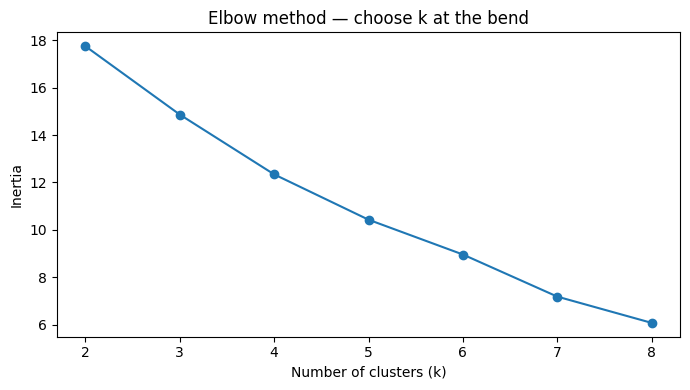

In [22]:
# Features used for clustering
FEATURE_COLS = [
    'pct_frontend', 'pct_backend', 'pct_test', 'pct_devops',
    'pct_docs', 'pct_build',
    'kw_frontend', 'kw_backend', 'kw_test', 'kw_devops', 'kw_docs'
]

X = df[FEATURE_COLS].fillna(0).values

# Normalize to [0, 1]
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Find best number of clusters using inertia (elbow method)
inertias = []
K_range  = range(2, min(9, len(df)))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method — choose k at the bend')
plt.tight_layout()
plt.show()

In [23]:
# Set k based on elbow plot above (default 4, adjust if needed)
K = 4

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print('Cluster distribution:')
print(df['cluster'].value_counts())

# Show average metrics per cluster to interpret them
cluster_summary = df.groupby('cluster')[FEATURE_COLS].mean().round(3)
print('\nCluster feature averages:')
cluster_summary

Cluster distribution:
cluster
0    10
1     8
3     6
2     4
Name: count, dtype: int64

Cluster feature averages:


,pct_frontend,pct_backend,pct_test,pct_devops,pct_docs,pct_build,kw_frontend,kw_backend,kw_test,kw_devops,kw_docs
cluster,,,,,,,,,,,
0,0.886,0.017,0.057,0.009,0.000,0.000,0.334,0.076,0.756,0.064,0.015
1,0.165,0.042,0.343,0.051,0.017,0.001,0.199,0.114,0.446,0.064,0.052
2,0.027,0.000,0.015,0.635,0.000,0.057,0.071,0.000,0.179,0.143,0.107
3,0.078,0.392,0.000,0.013,0.330,0.004,0.087,0.076,0.104,0.223,0.321


## 9. Visualizations

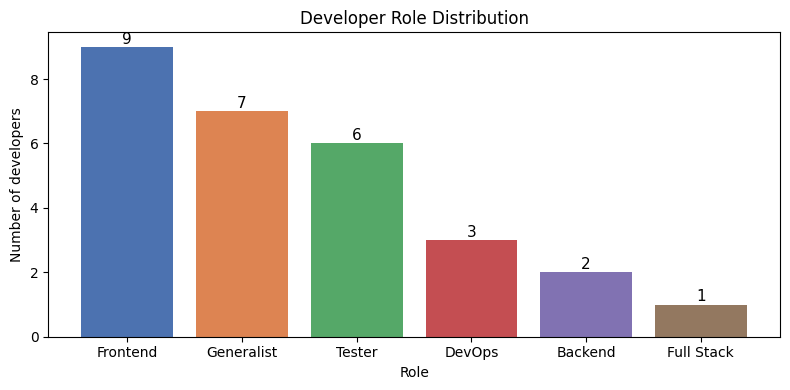

In [24]:
# --- 9.1 Role distribution bar chart ---
role_counts = df['role'].value_counts()

plt.figure(figsize=(8, 4))
bars = plt.bar(role_counts.index, role_counts.values,
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860'])
plt.title('Developer Role Distribution')
plt.xlabel('Role')
plt.ylabel('Number of developers')
for bar, val in zip(bars, role_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

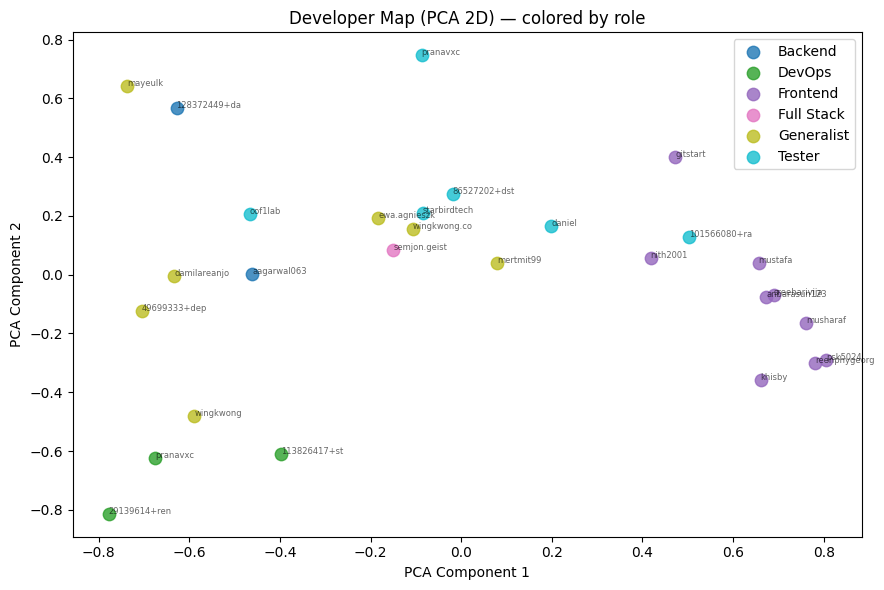

In [25]:
# --- 9.2 PCA scatter plot (2D) colored by role ---
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)

roles        = df['role'].values
unique_roles = sorted(set(roles))
colors       = cm.tab10(np.linspace(0, 1, len(unique_roles)))
color_map    = dict(zip(unique_roles, colors))

plt.figure(figsize=(9, 6))
for role in unique_roles:
    mask = roles == role
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=role, color=color_map[role], s=80, alpha=0.8)

# Annotate developer names (use short version)
for i, dev in enumerate(df.index):
    short = dev.split('@')[0][:12]
    plt.annotate(short, (X_pca[i, 0], X_pca[i, 1]),
                 fontsize=6, alpha=0.6)

plt.title('Developer Map (PCA 2D) — colored by role')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

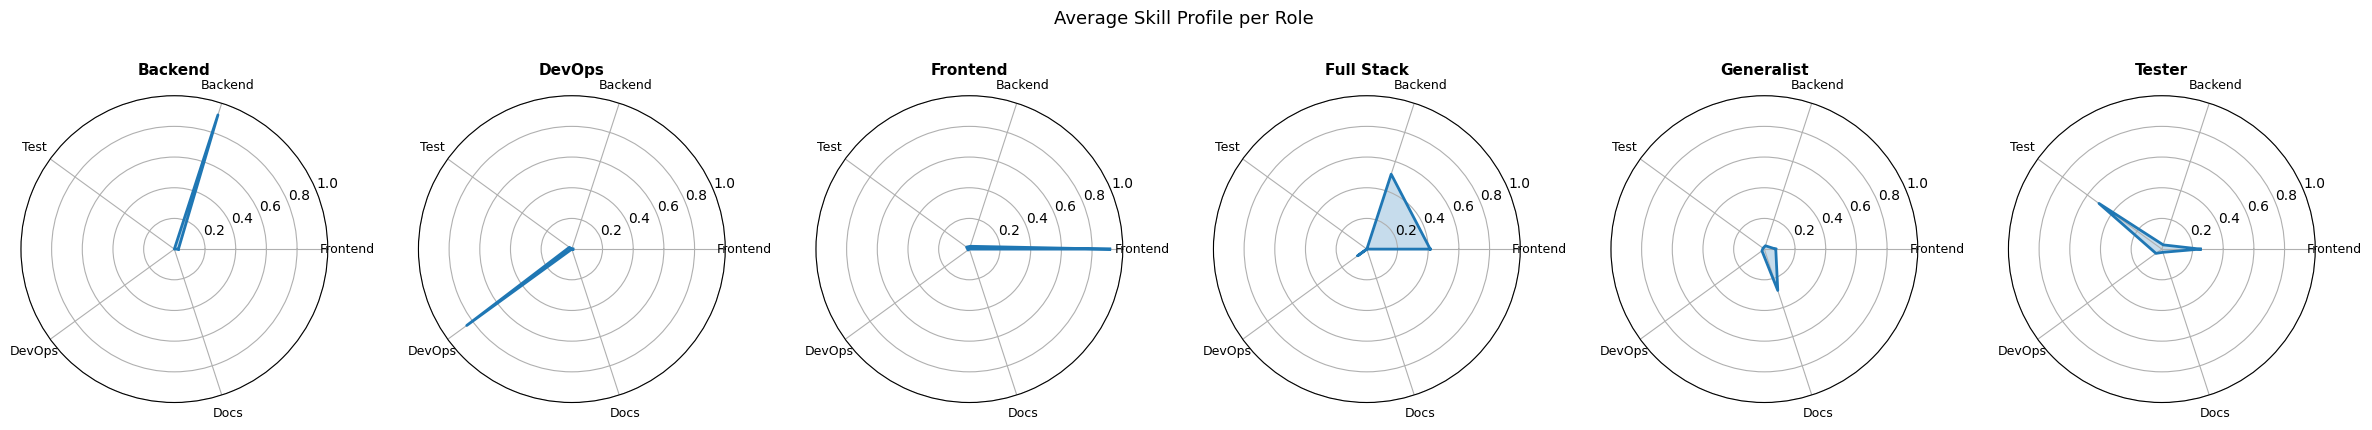

In [26]:
# --- 9.3 Radar chart: average profile per role ---
RADAR_FEATURES = ['pct_frontend', 'pct_backend', 'pct_test', 'pct_devops', 'pct_docs']
RADAR_LABELS   = ['Frontend', 'Backend', 'Test', 'DevOps', 'Docs']

role_avg = df.groupby('role')[RADAR_FEATURES].mean()

N      = len(RADAR_LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, len(role_avg), figsize=(4 * len(role_avg), 4),
                          subplot_kw=dict(polar=True))

if len(role_avg) == 1:
    axes = [axes]

for ax, (role, values) in zip(axes, role_avg.iterrows()):
    vals = values.tolist() + values.tolist()[:1]
    ax.plot(angles, vals, linewidth=2)
    ax.fill(angles, vals, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_LABELS, fontsize=9)
    ax.set_title(role, fontsize=11, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Average Skill Profile per Role', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

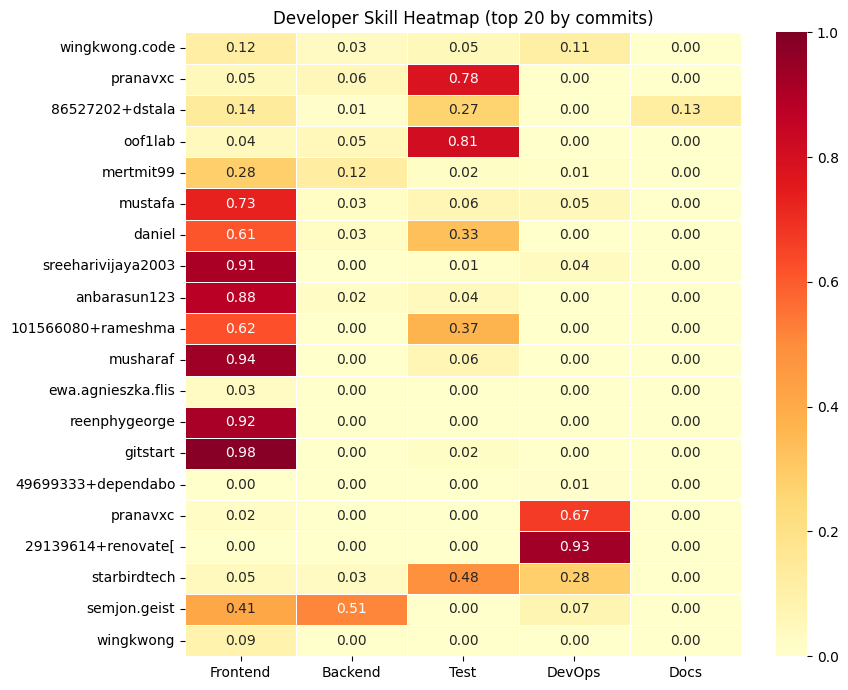

In [13]:
# --- 9.4 Heatmap: developer vs skill metrics ---
top_devs = df.nlargest(20, 'total_commits')  # show top 20 by commits
heat_data = top_devs[['pct_frontend', 'pct_backend', 'pct_test',
                        'pct_devops', 'pct_docs']].copy()
heat_data.index = [i.split('@')[0][:18] for i in heat_data.index]
heat_data.columns = ['Frontend', 'Backend', 'Test', 'DevOps', 'Docs']

plt.figure(figsize=(9, 7))
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Developer Skill Heatmap (top 20 by commits)')
plt.tight_layout()
plt.show()

## 10. Final results table

In [14]:
result = df[['total_commits', 'total_lines', 'pct_frontend', 'pct_backend',
             'pct_test', 'pct_devops', 'pct_docs', 'role', 'cluster']].copy()

result.columns = ['Commits', 'Lines', '% Frontend', '% Backend',
                  '% Test', '% DevOps', '% Docs', 'Role', 'Cluster']

# Format percentages
for col in ['% Frontend', '% Backend', '% Test', '% DevOps', '% Docs']:
    result[col] = (result[col] * 100).round(1).astype(str) + '%'

result.index = [i.split('@')[0] for i in result.index]
result.sort_values('Commits', ascending=False)

,Commits,Lines,% Frontend,% Backend,% Test,% DevOps,% Docs,Role,Cluster
wingkwong.code,2360,491691,11.9%,3.5%,4.9%,11.4%,0.3%,Generalist,1
pranavxc,1655,2880942,4.7%,5.7%,78.2%,0.1%,0.2%,Tester,1
86527202+dstala,1117,138374,14.0%,0.8%,26.9%,0.1%,12.6%,Tester,1
oof1lab,933,1578202,4.3%,5.1%,80.6%,0.0%,0.1%,Tester,1
mertmit99,768,163967,28.3%,12.4%,1.9%,1.4%,0.2%,Generalist,1
mustafa,667,31752,73.4%,2.7%,6.5%,5.0%,0.0%,Frontend,0
daniel,235,10885,61.2%,2.7%,32.8%,0.0%,0.2%,Tester,1
sreeharivijaya2003,208,8315,91.2%,0.1%,1.4%,3.8%,0.0%,Frontend,0
anbarasun123,191,8405,87.7%,2.2%,4.3%,0.0%,0.0%,Frontend,0
101566080+rameshmane7218,148,4571,62.2%,0.0%,37.0%,0.0%,0.0%,Tester,0
